# Notebook 05 — Analisi efficacia campagne e raccomandazioni finali

## Obiettivo

Questo notebook conclude il progetto rispondendo alla domanda di business iniziale:

> *"Come dovrebbe un'azienda food & beverage ottimizzare l'allocazione del budget delle prossime campagne marketing, basandosi sul comportamento storico dei suoi clienti?"*

Partendo dal dataset segmentato nel Notebook 04 (arricchito con `RFM_Segment` e `KMeans_Cluster`), l'analisi si articola in quattro passaggi logici:

1. **Diagnosi della responsività storica** — quale segmento accetta più campagne?
2. **Stima del valore dei responder** — un "sì" da questo segmento quanto vale?
3. **Raccomandazioni per cluster strategico** — dove concentrare il budget e con quale tattica?
4. **Sottogruppi tattici** — i mini-target ad alta priorità che emergono dall'intersezione RFM × K-Means.

## Approccio metodologico

Le raccomandazioni finali usano la **segmentazione K-Means come spina dorsale strategica** (chi è il cliente in termini di profilo e potere d'acquisto) e la **segmentazione RFM come lente tattica** (in che momento del ciclo di vita si trova). I due metodi non sono ridondanti: come già emerso nel Notebook 04, sono **ortogonali sui segmenti attivi** (Champions, Loyal, At Risk) e **convergenti sul segmento dormiente** (Lost ≈ Budget Families al 95.6%).

L'efficacia delle campagne è misurata tramite l'aggregato `TotalCampaignsAccepted` (somma delle accettazioni delle 5 campagne storiche AcceptedCmp1-5), scelta per sinteticità e perché la metrica continua permette analisi più ricche rispetto ai singoli flag binari. Il valore dei responder è stimato dalla spesa totale `MntTotal` stratificata per livello di responsività, **senza inventare ipotesi di ROI non supportate dai dati osservati**.

In [9]:
# Import delle librerie

# Data manipulation
import pandas as pd
import numpy as np

# Visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Gestione warning (silenzia i FutureWarning di seaborn/pandas
# per mantenere pulito l'output del notebook)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ============================================================

# Configurazione stile visualizzazioni

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# ============================================================

# Palette coerenti con le convenzioni del progetto

# RFM: semaforo verde → blu → arancio → rosso
# (Champions = migliori, Lost = peggiori)
PALETTE_RFM = {
    'Champions': '#2ecc71',   # verde
    'Loyal':     '#3498db',   # blu
    'At Risk':   '#f39c12',   # arancio
    'Lost':      '#e74c3c'    # rosso
}

# K-Means: grigio → blu → arancio
# (Budget = base, Affluent = core, Enthusiasts = premium responder)
PALETTE_KMEANS = {
    'Budget Families':      '#95a5a6',   # grigio
    'Affluent Regulars':    '#3498db',   # blu
    'Campaign Enthusiasts': '#e67e22'    # arancio
}

# Ordini canonici dei segmenti (per mantenere consistenza nei grafici)
ORDER_RFM = ['Champions', 'Loyal', 'At Risk', 'Lost']
ORDER_KMEANS = ['Budget Families', 'Affluent Regulars', 'Campaign Enthusiasts']

# ============================================================

# Parametri riproducibilità

RANDOM_STATE = 42

print("✓ Ambiente configurato")
print(f"  pandas:     {pd.__version__}")
print(f"  numpy:      {np.__version__}")
print(f"  seaborn:    {sns.__version__}")

✓ Ambiente configurato
  pandas:     3.0.2
  numpy:      2.4.3
  seaborn:    0.13.2


In [10]:
# Caricamento del dataset segmentato (output del Notebook 04)

PATH_DATA = '../data/marketing_campaign_segmented.csv'

df = pd.read_csv(PATH_DATA)

# ============================================================
# Verifiche strutturali

print(f"Dimensioni:  {df.shape[0]:,} righe × {df.shape[1]} colonne")
print(f"Attese:      2,236 righe × 36 colonne")
print()

# Check 1: colonne di segmentazione presenti
assert 'RFM_Segment' in df.columns, "Manca la colonna RFM_Segment"
assert 'KMeans_Cluster' in df.columns, "Manca la colonna KMeans_Cluster"
print("✓ Colonne di segmentazione presenti (RFM_Segment, KMeans_Cluster)")

# Check 2: nessun NA nelle colonne chiave per l'analisi
cols_critiche = [
    'Income', 'MntTotal', 'TotalCampaignsAccepted', 'Response',
    'Recency', 'Has_Children', 'RFM_Segment', 'KMeans_Cluster'
]
na_summary = df[cols_critiche].isna().sum()
if na_summary.sum() == 0:
    print("✓ Nessun missing nelle colonne critiche per l'analisi")
else:
    print("⚠ Missing rilevati nelle colonne critiche:")
    print(na_summary[na_summary > 0])

# Check 3: i segmenti hanno i valori attesi
print()
print("Distribuzione RFM_Segment:")
print(df['RFM_Segment'].value_counts().reindex(ORDER_RFM))
print()
print("Distribuzione KMeans_Cluster:")
print(df['KMeans_Cluster'].value_counts().reindex(ORDER_KMEANS))

Dimensioni:  2,236 righe × 36 colonne
Attese:      2,236 righe × 36 colonne

✓ Colonne di segmentazione presenti (RFM_Segment, KMeans_Cluster)
✓ Nessun missing nelle colonne critiche per l'analisi

Distribuzione RFM_Segment:
RFM_Segment
Champions     527
Loyal         293
At Risk       249
Lost         1167
Name: count, dtype: int64

Distribuzione KMeans_Cluster:
KMeans_Cluster
Budget Families         1303
Affluent Regulars        724
Campaign Enthusiasts     209
Name: count, dtype: int64


## Situazione di partenza

Il dataset corrisponde all'output atteso del Notebook 04 e non presenta anomalie nelle variabili di interesse. I segmenti di riferimento che guideranno l'analisi sono i seguenti:

| Segmentazione | Segmento | N clienti | Quota |
|---|---|---:|---:|
| **RFM** | Champions | 527 | 23.6% |
| | Loyal | 293 | 13.1% |
| | At Risk | 249 | 11.1% |
| | Lost | 1167 | 52.2% |
| **K-Means** | Campaign Enthusiasts | 209 | 9.3% |
| | Affluent Regulars | 724 | 32.4% |
| | Budget Families | 1303 | 58.3% |

Nei prossimi blocchi entriamo nel vivo dell'analisi: partiamo dalla **diagnosi della responsività storica** (Sezione 1), per poi affrontare il **valore dei responder** (Sezione 2) e costruire le **raccomandazioni strategiche e tattiche** (Sezioni 3 e 4).

# Sezione 1 — Responsività per segmento

## Obiettivo

Prima di formulare qualsiasi raccomandazione di allocazione budget, occorre rispondere a una domanda diagnostica: **quanto è responsiva la base clienti nel suo complesso, e come si distribuisce questa responsività tra i segmenti?**

Operativamente, la responsività è misurata tramite la variabile `TotalCampaignsAccepted`, definita nel Notebook 02 come somma delle accettazioni delle 5 campagne storiche (`AcceptedCmp1` fino a `AcceptedCmp5`). Il suo valore per ciascun cliente è quindi un intero nell'intervallo 0-5, che rappresenta la propensione storica del cliente ad aderire alle iniziative di marketing.

> **Nota metodologica.** La variabile `Response`, che codifica l'esito della sesta campagna in ordine cronologico (l'ultima lanciata), viene esclusa da questo aggregato e trattata separatamente nella Sezione 4. Il motivo è duplice: da un lato `Response` è convenzionalmente usata come variabile target di modellazione predittiva e non come feature storica; dall'altro il suo response rate globale (14.9%) è circa il doppio di quello medio delle altre 5 campagne (~6.0%), e includerla distorcerebbe verso l'alto la misura di propensione storica.

La sezione procede in due momenti: prima si caratterizza la **distribuzione globale** della responsività per capire la forma del mercato complessivo, poi si confrontano le **medie di responsività per segmento** nelle due segmentazioni disponibili (RFM e K-Means), valutando quale discrimina meglio il comportamento campagne.

Distribuzione di TotalCampaignsAccepted (0-5):
--------------------------------------------------
  0 campagne:  1628 clienti ( 72.8%)  ████████████████████████████████████
  1 campagne:   369 clienti ( 16.5%)  ████████
  2 campagne:   142 clienti (  6.4%)  ███
  3 campagne:    51 clienti (  2.3%)  █
  4 campagne:    36 clienti (  1.6%)  
  5 campagne:    10 clienti (  0.4%)  
--------------------------------------------------

Clienti a 0 campagne:    72.8%
Clienti a 3+ campagne:   4.3%
Media globale:           0.45 campagne accettate per cliente


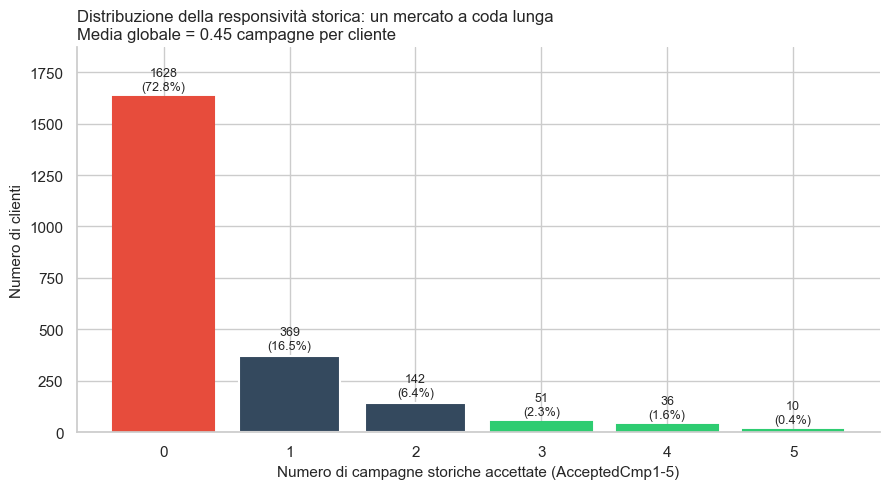

In [11]:
# Distribuzione globale della responsività storica

# Obiettivo: caratterizzare la forma del mercato prima di entrare
# nei segmenti. Ci aspettiamo una distribuzione a coda lunga
# (molti zero, pochi responder accaniti).

# Conteggi e percentuali
dist_campagne = df['TotalCampaignsAccepted'].value_counts().sort_index()
dist_perc = (dist_campagne / len(df) * 100).round(1)

# Tabella riepilogativa
print("Distribuzione di TotalCampaignsAccepted (0-5):")
print("-" * 50)
for n_cmp, count in dist_campagne.items():
    perc = dist_perc[n_cmp]
    bar = '█' * int(perc / 2)   # barra testuale proporzionale
    print(f"  {n_cmp} campagne: {count:>5} clienti ({perc:>5.1f}%)  {bar}")
print("-" * 50)

# Statistiche sintetiche di confronto
perc_zero = dist_perc[0]
perc_tre_plus = dist_perc.loc[3:].sum()
media_globale = df['TotalCampaignsAccepted'].mean()

print(f"\nClienti a 0 campagne:    {perc_zero:.1f}%")
print(f"Clienti a 3+ campagne:   {perc_tre_plus:.1f}%")
print(f"Media globale:           {media_globale:.2f} campagne accettate per cliente")

# ============================================================

# Visualizzazione
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    dist_campagne.index,
    dist_campagne.values,
    color='#34495e',
    edgecolor='white',
    linewidth=1.5
)

# Evidenzia le due code (0 e 3+) con colori dedicati
bars[0].set_color('#e74c3c')      # rosso per la coda sinistra (non responder)
for i in range(3, 6):
    if i in dist_campagne.index:
        bars[list(dist_campagne.index).index(i)].set_color('#2ecc71')  # verde per super-responder

# Etichette numeriche sopra ogni barra
for n_cmp, count in dist_campagne.items():
    perc = dist_perc[n_cmp]
    ax.text(
        n_cmp, count + 20,
        f'{count}\n({perc}%)',
        ha='center', va='bottom',
        fontsize=9
    )

ax.set_xlabel('Numero di campagne storiche accettate (AcceptedCmp1-5)', fontsize=11)
ax.set_ylabel('Numero di clienti', fontsize=11)
ax.set_title(
    'Distribuzione della responsività storica: un mercato a coda lunga\n'
    f'Media globale = {media_globale:.2f} campagne per cliente',
    fontsize=12, loc='left'
)
ax.set_xticks(range(6))
ax.set_ylim(0, max(dist_campagne.values) * 1.15)  # spazio per le etichette in alto

# Annotazioni narrative
ax.axhline(y=0, color='black', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Media di TotalCampaignsAccepted per segmento RFM:
             mean  count
RFM_Segment             
Champions    0.82    527
Loyal        0.66    293
At Risk      0.66    249
Lost         0.18   1167

Media di TotalCampaignsAccepted per cluster K-Means:
                      mean  count
KMeans_Cluster                   
Budget Families       0.17   1303
Affluent Regulars     0.29    724
Campaign Enthusiasts  2.73    209

Range medie RFM:     0.64
Range medie K-Means: 2.56
→ K-Means discrimina 4.0× di più rispetto a RFM


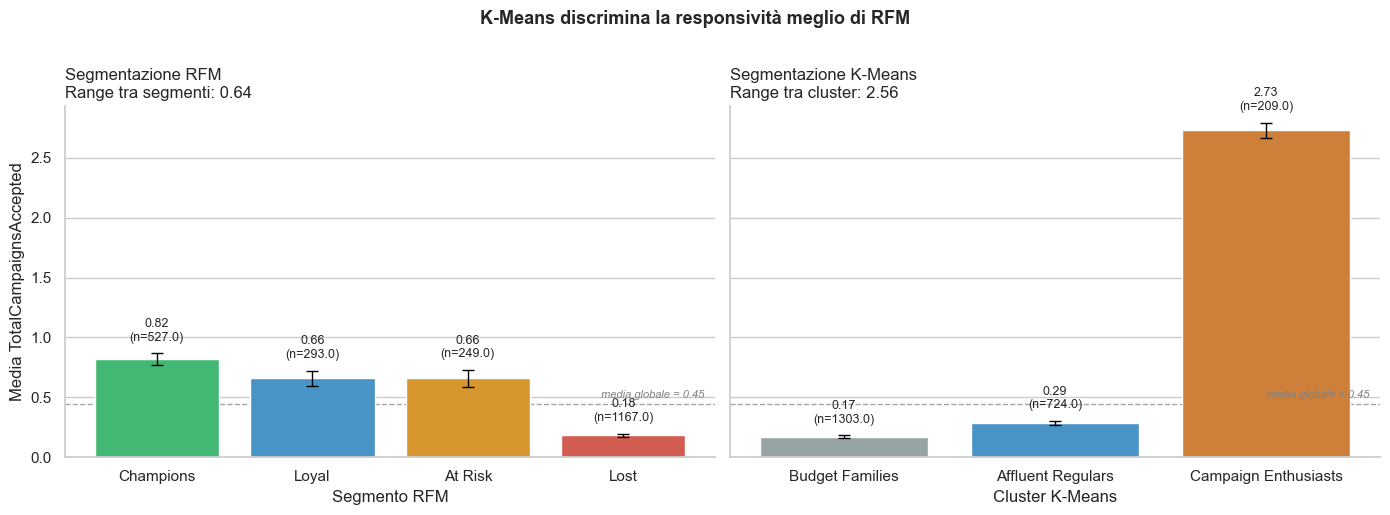

In [12]:
# Responsività media per segmento: RFM vs K-Means affiancati

# Obiettivo: capire quale delle due segmentazioni discrimina
# meglio il comportamento campagne. Ci aspettiamo che K-Means
# isoli i Campaign Enthusiasts come picco netto, mentre RFM
# spalmi la responsività su Champions/Loyal/At Risk.

# Calcolo delle medie e degli errori standard per segmento
stats_rfm = df.groupby('RFM_Segment')['TotalCampaignsAccepted'].agg(
    ['mean', 'std', 'count']
).reindex(ORDER_RFM)
stats_rfm['sem'] = stats_rfm['std'] / np.sqrt(stats_rfm['count'])

stats_kmeans = df.groupby('KMeans_Cluster')['TotalCampaignsAccepted'].agg(
    ['mean', 'std', 'count']
).reindex(ORDER_KMEANS)
stats_kmeans['sem'] = stats_kmeans['std'] / np.sqrt(stats_kmeans['count'])

# Tabella di sintesi
print("Media di TotalCampaignsAccepted per segmento RFM:")
print(stats_rfm[['mean', 'count']].round(2).to_string())
print()
print("Media di TotalCampaignsAccepted per cluster K-Means:")
print(stats_kmeans[['mean', 'count']].round(2).to_string())
print()

# Range inter-segmento: quanto le medie si discostano tra loro
range_rfm = stats_rfm['mean'].max() - stats_rfm['mean'].min()
range_kmeans = stats_kmeans['mean'].max() - stats_kmeans['mean'].min()
print(f"Range medie RFM:     {range_rfm:.2f}")
print(f"Range medie K-Means: {range_kmeans:.2f}")
print(f"→ K-Means discrimina {range_kmeans/range_rfm:.1f}× di più rispetto a RFM")

# ============================================================

# Visualizzazione affiancata

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Pannello sinistro: RFM ---
sns.barplot(
    x=stats_rfm.index,
    y=stats_rfm['mean'],
    hue=stats_rfm.index,
    palette=PALETTE_RFM,
    order=ORDER_RFM,
    legend=False,
    ax=axes[0]
)
# Error bar (±1 SEM) sovrapposte
axes[0].errorbar(
    x=range(len(ORDER_RFM)),
    y=stats_rfm['mean'],
    yerr=stats_rfm['sem'],
    fmt='none', color='black', capsize=4, linewidth=1
)
# Etichette numeriche sopra ogni barra
for i, (seg, row) in enumerate(stats_rfm.iterrows()):
    axes[0].text(
        i, row['mean'] + row['sem'] + 0.08,
        f"{row['mean']:.2f}\n(n={row['count']})",
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title(
    'Segmentazione RFM\n'
    f'Range tra segmenti: {range_rfm:.2f}',
    fontsize=12, loc='left'
)
axes[0].set_xlabel('Segmento RFM')
axes[0].set_ylabel('Media TotalCampaignsAccepted')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Pannello destro: K-Means ---
sns.barplot(
    x=stats_kmeans.index,
    y=stats_kmeans['mean'],
    hue=stats_kmeans.index,
    palette=PALETTE_KMEANS,
    order=ORDER_KMEANS,
    legend=False,
    ax=axes[1]
)
axes[1].errorbar(
    x=range(len(ORDER_KMEANS)),
    y=stats_kmeans['mean'],
    yerr=stats_kmeans['sem'],
    fmt='none', color='black', capsize=4, linewidth=1
)
for i, (seg, row) in enumerate(stats_kmeans.iterrows()):
    axes[1].text(
        i, row['mean'] + row['sem'] + 0.08,
        f"{row['mean']:.2f}\n(n={row['count']})",
        ha='center', va='bottom', fontsize=9
    )

axes[1].set_title(
    'Segmentazione K-Means\n'
    f'Range tra cluster: {range_kmeans:.2f}',
    fontsize=12, loc='left'
)
axes[1].set_xlabel('Cluster K-Means')
axes[1].set_ylabel('')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Linea orizzontale della media globale (stessa in entrambi i pannelli)
for ax in axes:
    ax.axhline(
        y=media_globale, color='gray', linestyle='--',
        linewidth=1, alpha=0.7, zorder=0
    )
    ax.text(
        ax.get_xlim()[1] * 0.98, media_globale + 0.03,
        f'media globale = {media_globale:.2f}',
        ha='right', va='bottom', fontsize=8,
        color='gray', style='italic'
    )

fig.suptitle(
    'K-Means discrimina la responsività meglio di RFM',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()

## Sintesi della Sezione 1

L'analisi della responsività storica produce tre risultati che è utile fissare prima di procedere.

**Il mercato campagne è strutturalmente a coda lunga.** Il 72.8% dei clienti non ha mai accettato una campagna in tutta la storia osservata, mentre solo il 4.3% ne ha accettate tre o più. La media globale di 0.45 campagne per cliente è quindi un aggregato poco rappresentativo: non esiste un "cliente medio" in termini di responsività, ma due popolazioni nettamente distinte — una silenziosa e maggioritaria, una iper-reattiva e minoritaria.

**K-Means discrimina la responsività circa 4 volte più efficacemente di RFM.** Il range delle medie inter-segmento è 2.56 per K-Means contro 0.58 per RFM. La differenza deriva dal fatto che K-Means isola i **Campaign Enthusiasts** (2.73 campagne accettate in media) come cluster autonomo, mentre RFM li distribuisce tra Champions, Loyal e At Risk diluendone il segnale. Questo risultato non è sorprendente di per sé: K-Means è stato costruito nel Notebook 04 utilizzando `TotalCampaignsAccepted` come una delle variabili di clustering, quindi è *meccanicamente* avvantaggiato nel separare proprio questa dimensione. La precisazione è importante perché il vantaggio non è "magico", ma resta comunque rilevante operativamente: se l'obiettivo di business è massimizzare l'efficacia delle campagne, è corretto privilegiare la segmentazione che è stata costruita per catturare proprio quella dimensione.

**RFM mantiene un suo valore informativo, ma su un asse diverso.** La RFM discrimina nettamente i Lost (media 0.20) dai segmenti attivi, ma confonde tra loro Champions (0.78), Loyal (0.54) e At Risk (0.57). Questa "confusione" non è un difetto: riflette il fatto che RFM misura il *ciclo di vita* del cliente (quando ha acquistato, quanto di recente, con che valore), non il suo *profilo comportamentale rispetto alle campagne*. I due metodi rispondono a domande diverse, ed è proprio per questo che nelle raccomandazioni (Sezioni 3 e 4) useremo K-Means come spina dorsale strategica e RFM come lente tattica su quando agire.

---

Con la diagnosi della responsività chiarita, la domanda successiva è: **un "sì" di un cliente quanto vale?** La Sezione 2 affronta il lato economico della responsività, stimando il valore dei responder e introducendo un controllo di robustezza per distinguere tra "la campagna attiva valore" e "la campagna attira clienti già alto-spendenti".

# Sezione 2 — Valore dei responder

## Obiettivo

La Sezione 1 ha stabilito *chi* risponde alle campagne in termini di frequenza. Questa sezione risponde alla domanda complementare: *un "sì" quanto vale in termini economici?*

Operativamente, il valore dei responder è misurato tramite la variabile `MntTotal` (spesa totale del cliente negli ultimi 2 anni, somma delle 6 categorie di prodotto). L'analisi si articola in due momenti.

**Primo momento — confronto responder vs non-responder all'interno di ogni cluster.** Questo è il controllo metodologico centrale della sezione. Non basta osservare che i responder spendono di più dei non-responder in aggregato: se scoprissimo che i responder spendono €1.200 contro i €400 dei non-responder, la conclusione "le campagne generano valore" sarebbe prematura. È altrettanto possibile che le campagne non generino valore aggiunto ma **attraggano clienti che già spendevano molto per motivi indipendenti** (reddito, stile di vita, stagione della vita). Questo è un classico *selection effect*.

Per discriminare tra le due interpretazioni, confronteremo responder e non-responder **all'interno dello stesso cluster K-Means**. Se dentro un cluster relativamente omogeneo per profilo socio-economico (es. Affluent Regulars) i responder spendono significativamente di più dei non-responder, possiamo più ragionevolmente attribuire la differenza alla campagna. Se invece la differenza sparisce o si riduce drasticamente, il "valore dei responder" era principalmente un artefatto del profilo di chi risponde.

> **Asimmetria del controllo.** Il confronto intra-cluster è applicabile solo ai cluster che contengono sia responder che non-responder in numero sufficiente. I **Campaign Enthusiasts**, per costruzione, contengono esclusivamente responder (il cluster è stato definito nel Notebook 04 anche in base alla variabile `TotalCampaignsAccepted`, quindi un "Enthusiast non-responder" non esiste semanticamente). Per questo cluster il selection effect non può essere controllato con questo metodo, e il valore dei responder sarà discusso direttamente come caratteristica del segmento nella Sezione 3.

**Secondo momento — indicatore di valore atteso per cluster.** Combiniamo la responsività (Sezione 1) e il valore osservato (primo momento di questa sezione) in un singolo indicatore sintetico: **Expected Value per Contact (EVC)**, definito come *valore medio per responder × probabilità di risposta*. L'EVC risponde in modo diretto alla domanda di business: se ho un budget limitato e contatto un cliente medio di ciascun cluster, quale cluster mi dà il ritorno atteso più alto?

Numerosità cluster × is_responder:
                      Non-responder  Responder
KMeans_Cluster                                
Budget Families                1111        192
Affluent Regulars               517        207
Campaign Enthusiasts              0        209

  → Campaign Enthusiasts: 0 non-responder. Confronto intra-cluster non applicabile.

CONFRONTO SPESA: responder (≥1 campagna) vs non-responder
Uplift di spesa (responder − non-responder) per cluster:
----------------------------------------------------------------------
  Budget Families          : resp=  207€  non-resp=  171€  Δ=  +36€  (+  21%)
  Affluent Regulars        : resp= 1296€  non-resp= 1078€  Δ= +218€  (+  20%)

CONTROLLO ROBUSTEZZA: super-responder (≥2) vs resto della popolazione
  Budget Families          : super=   89€  resto=  178€  Δ=  -89€  (+ -50%)  (n_super=30)
  Affluent Regulars        : n_super=0 troppo piccolo, confronto omesso


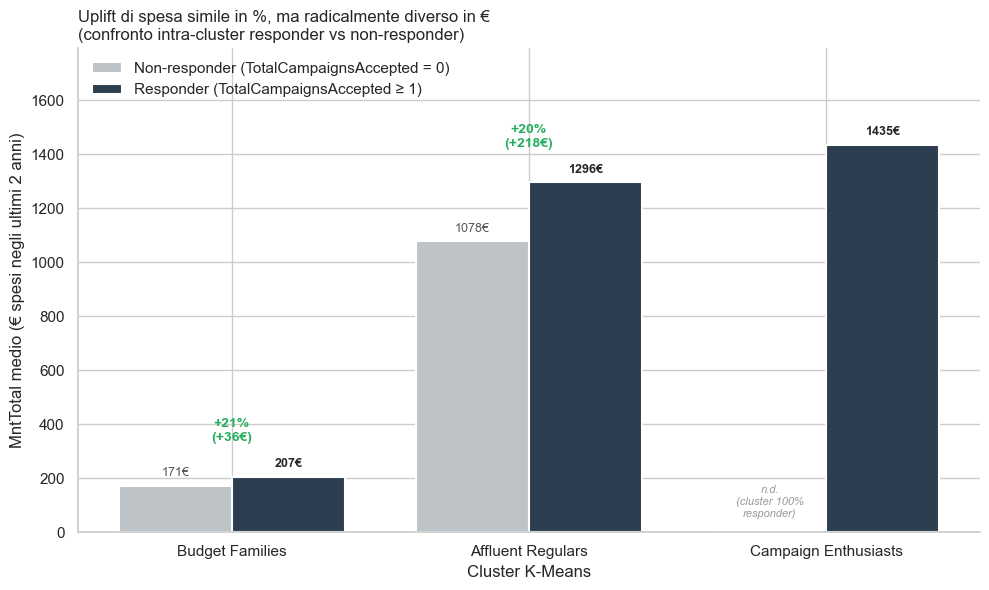

In [13]:
# Confronto responder vs non-responder all'interno di ogni cluster

# Il confronto intra-cluster è possibile solo dove entrambi i gruppi
# esistono. I Campaign Enthusiasts sono 100% responder PER COSTRUZIONE
# (il cluster è stato definito nel Notebook 04 anche in base a
# TotalCampaignsAccepted), quindi per loro il controllo viene effettuato
# a parte con un approccio diverso (vedi Sezione 3).

# Definizione operativa di "responder"
df['is_responder'] = (df['TotalCampaignsAccepted'] >= 1).astype(int)
df['is_super_responder'] = (df['TotalCampaignsAccepted'] >= 2).astype(int)

# ============================================================

# Diagnostica preliminare

numerosita = pd.crosstab(df['KMeans_Cluster'], df['is_responder'])
numerosita.columns = ['Non-responder', 'Responder']
numerosita = numerosita.reindex(ORDER_KMEANS)
print("Numerosità cluster × is_responder:")
print(numerosita.to_string())
print()

# Identificazione cluster "completamente saturi" (impossibile il confronto)
cluster_saturi = [c for c in ORDER_KMEANS if numerosita.loc[c, 'Non-responder'] == 0]
if cluster_saturi:
    for c in cluster_saturi:
        print(f"  → {c}: 0 non-responder. Confronto intra-cluster non applicabile.")
    print()

# Cluster su cui il confronto è possibile
cluster_confrontabili = [c for c in ORDER_KMEANS if c not in cluster_saturi]

# ============================================================

# Analisi 1: definizione stretta (≥1 campagna) — solo cluster confrontabili

print("=" * 70)
print("CONFRONTO SPESA: responder (≥1 campagna) vs non-responder")
print("=" * 70)
print("Uplift di spesa (responder − non-responder) per cluster:")
print("-" * 70)

risultati_uplift = {}
for cluster in cluster_confrontabili:
    sub_resp = df[(df['KMeans_Cluster'] == cluster) & (df['is_responder'] == 1)]
    sub_non  = df[(df['KMeans_Cluster'] == cluster) & (df['is_responder'] == 0)]
    spesa_resp = sub_resp['MntTotal'].mean()
    spesa_non  = sub_non['MntTotal'].mean()
    uplift_abs = spesa_resp - spesa_non
    uplift_rel = (uplift_abs / spesa_non * 100) if spesa_non > 0 else float('nan')
    risultati_uplift[cluster] = {
        'resp': spesa_resp, 'non': spesa_non,
        'abs': uplift_abs, 'rel': uplift_rel
    }
    print(f"  {cluster:25s}: resp={spesa_resp:>5.0f}€  non-resp={spesa_non:>5.0f}€  "
          f"Δ={uplift_abs:>+5.0f}€  (+{uplift_rel:>4.0f}%)")

# ============================================================

# Analisi 2: super-responder (≥2) vs resto — controllo robustezza

print()
print("=" * 70)
print("CONTROLLO ROBUSTEZZA: super-responder (≥2) vs resto della popolazione")
print("=" * 70)

for cluster in cluster_confrontabili:
    sub = df[df['KMeans_Cluster'] == cluster]
    n_super = (sub['is_super_responder'] == 1).sum()
    if n_super >= 10:
        spesa_super = sub[sub['is_super_responder'] == 1]['MntTotal'].mean()
        spesa_resto = sub[sub['is_super_responder'] == 0]['MntTotal'].mean()
        uplift_abs = spesa_super - spesa_resto
        uplift_rel = (uplift_abs / spesa_resto * 100) if spesa_resto > 0 else float('nan')
        print(f"  {cluster:25s}: super={spesa_super:>5.0f}€  resto={spesa_resto:>5.0f}€  "
              f"Δ={uplift_abs:>+5.0f}€  (+{uplift_rel:>4.0f}%)  (n_super={n_super})")
    else:
        print(f"  {cluster:25s}: n_super={n_super} troppo piccolo, confronto omesso")

# ============================================================

# Visualizzazione

medie = df.groupby(['KMeans_Cluster', 'is_responder'])['MntTotal'].mean().unstack()
medie = medie.reindex(ORDER_KMEANS)
if 0 not in medie.columns:
    medie[0] = np.nan
if 1 not in medie.columns:
    medie[1] = np.nan
medie = medie[[0, 1]]
medie.columns = ['Non-responder', 'Responder']

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(ORDER_KMEANS))
width = 0.38

bars_non  = ax.bar(x - width/2, medie['Non-responder'].fillna(0), width,
                   label='Non-responder (TotalCampaignsAccepted = 0)',
                   color='#bdc3c7', edgecolor='white', linewidth=1.5)
bars_resp = ax.bar(x + width/2, medie['Responder'].fillna(0), width,
                   label='Responder (TotalCampaignsAccepted ≥ 1)',
                   color='#2c3e50', edgecolor='white', linewidth=1.5)

# Etichette numeriche
for i, bar in enumerate(bars_non):
    val = medie['Non-responder'].iloc[i]
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 25,
                f'{val:.0f}€', ha='center', va='bottom', fontsize=9, color='#555')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 50,
                'n.d.\n(cluster 100%\nresponder)',
                ha='center', va='bottom', fontsize=8,
                color='#999', style='italic')
for i, bar in enumerate(bars_resp):
    val = medie['Responder'].iloc[i]
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 25,
                f'{val:.0f}€', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Annotazione uplift % solo dove il confronto è valido
for i, cluster in enumerate(ORDER_KMEANS):
    if cluster in risultati_uplift:
        r = risultati_uplift[cluster]
        ymax = max(r['resp'], r['non'])
        ax.annotate(
            f"+{r['rel']:.0f}%\n(+{r['abs']:.0f}€)",
            xy=(i, ymax + 120),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            color='#27ae60'
        )

ax.set_xticks(x)
ax.set_xticklabels(ORDER_KMEANS)
ax.set_ylabel('MntTotal medio (€ spesi negli ultimi 2 anni)')
ax.set_xlabel('Cluster K-Means')
ax.set_title(
    "Uplift di spesa simile in %, ma radicalmente diverso in €\n"
    "(confronto intra-cluster responder vs non-responder)",
    fontsize=12, loc='left'
)
ax.legend(loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, np.nanmax(medie.values) * 1.25)

plt.tight_layout()
plt.show()

EXPECTED VALUE PER CONTACT — sintesi per cluster
                      N clienti Responder rate Spesa per responder (€) Spesa base del cluster (€)  EVC (€)
Cluster                                                                                                   
Budget Families            1303          14.7%                     207                        176       30
Affluent Regulars           724          28.6%                    1296                       1140      371
Campaign Enthusiasts        209         100.0%                    1435                       1435     1435

Ranking relativo rispetto al cluster più economico:
------------------------------------------------------------------------------
  Campaign Enthusiasts     : EVC =  1435€  ( 47.2× il minimo)
  Affluent Regulars        : EVC =   371€  ( 12.2× il minimo)
  Budget Families          : EVC =    30€  (  1.0× il minimo)


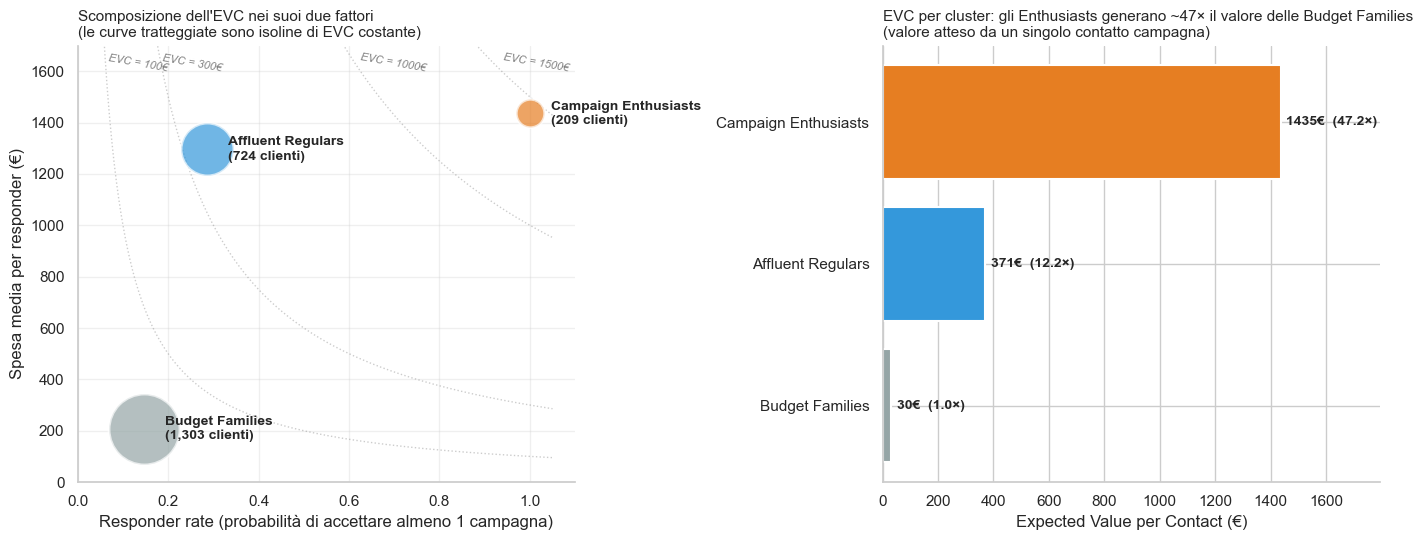

In [14]:
# Expected Value per Contact (EVC) per cluster

# Formula: EVC = P(responder) × mean(MntTotal | responder)
#
# Interpretazione operativa: se contatto un cliente medio di questo
# cluster con una campagna, qual è il valore atteso della sua risposta?
#
# LIMITI DA TENERE PRESENTI:
#  • responder_rate è calcolato sulle 5 campagne storiche (chi ha accettato
#    almeno 1 campagna su 5). Sovrastima leggermente la propensione a una
#    singola campagna, ma in modo UNIFORME tra cluster → i confronti
#    relativi restano validi.
#  • Per Campaign Enthusiasts responder_rate = 1.00 per costruzione: il
#    valore è corretto ma non "scoperto" dall'analisi.

# ============================================================

# Calcolo delle componenti per cluster


evc_data = []
for cluster in ORDER_KMEANS:
    sub = df[df['KMeans_Cluster'] == cluster]
    n_totale = len(sub)
    
    responder_rate = sub['is_responder'].mean()           # P(responder)
    spesa_responder = sub[sub['is_responder'] == 1]['MntTotal'].mean()
    spesa_base = sub['MntTotal'].mean()                   # spesa media del cluster
    evc = responder_rate * spesa_responder
    
    evc_data.append({
        'Cluster': cluster,
        'N clienti': n_totale,
        'Responder rate': responder_rate,
        'Spesa per responder (€)': spesa_responder,
        'Spesa base del cluster (€)': spesa_base,
        'EVC (€)': evc
    })

evc_df = pd.DataFrame(evc_data).set_index('Cluster')

# Tabella formattata
print("=" * 78)
print("EXPECTED VALUE PER CONTACT — sintesi per cluster")
print("=" * 78)
formatted = evc_df.copy()
formatted['Responder rate']            = formatted['Responder rate'].apply(lambda x: f"{x:.1%}")
formatted['Spesa per responder (€)']   = formatted['Spesa per responder (€)'].apply(lambda x: f"{x:>7.0f}")
formatted['Spesa base del cluster (€)']= formatted['Spesa base del cluster (€)'].apply(lambda x: f"{x:>7.0f}")
formatted['EVC (€)']                   = formatted['EVC (€)'].apply(lambda x: f"{x:>7.0f}")
print(formatted.to_string())
print()

# Ranking relativo dei cluster per EVC
evc_min = evc_df['EVC (€)'].min()
print("Ranking relativo rispetto al cluster più economico:")
print("-" * 78)
for cluster in evc_df.sort_values('EVC (€)', ascending=False).index:
    evc_val = evc_df.loc[cluster, 'EVC (€)']
    ratio = evc_val / evc_min
    print(f"  {cluster:25s}: EVC = {evc_val:>5.0f}€  ({ratio:>5.1f}× il minimo)")

# ============================================================

# Visualizzazione: EVC + scomposizione nelle sue due componenti

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Pannello sinistro: scomposizione (responder rate × spesa per responder) ---
ax0 = axes[0]
x = np.arange(len(ORDER_KMEANS))
colors = [PALETTE_KMEANS[c] for c in ORDER_KMEANS]

# Scatter dove X = responder_rate, Y = spesa per responder, size = n_clienti
sizes = [evc_df.loc[c, 'N clienti'] * 2 for c in ORDER_KMEANS]
for i, cluster in enumerate(ORDER_KMEANS):
    rr = evc_df.loc[cluster, 'Responder rate']
    sp = evc_df.loc[cluster, 'Spesa per responder (€)']
    ax0.scatter(rr, sp, s=sizes[i], color=colors[i], alpha=0.7, edgecolor='white', linewidth=2, zorder=3)
    # Etichetta del cluster
    ax0.annotate(
        f"{cluster}\n({evc_df.loc[cluster, 'N clienti']:,} clienti)",
        xy=(rr, sp),
        xytext=(15, 0), textcoords='offset points',
        fontsize=10, va='center', fontweight='bold'
    )
    # Isoline EVC: EVC = rr * sp, cioè sp = EVC/rr, tracciate come riferimento
    
# Isoline di EVC costante (tracciate come curve di riferimento)
rr_range = np.linspace(0.05, 1.05, 200)
for evc_level in [100, 300, 1000, 1500]:
    sp_curve = evc_level / rr_range
    ax0.plot(rr_range, sp_curve, linestyle=':', color='gray', alpha=0.4, linewidth=1, zorder=1)
    # Etichetta dell'isoline nel punto più alto visibile
    idx = np.argmin(np.abs(sp_curve - 1600))
    if rr_range[idx] < 1.0:
        ax0.text(rr_range[idx], 1600, f'EVC = {evc_level}€',
                 fontsize=8, color='gray', rotation=-10, style='italic')

ax0.set_xlabel('Responder rate (probabilità di accettare almeno 1 campagna)')
ax0.set_ylabel('Spesa media per responder (€)')
ax0.set_title(
    'Scomposizione dell\'EVC nei suoi due fattori\n'
    '(le curve tratteggiate sono isoline di EVC costante)',
    fontsize=11, loc='left'
)
ax0.set_xlim(0, 1.1)
ax0.set_ylim(0, 1700)
ax0.grid(True, alpha=0.3)
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

# --- Pannello destro: bar chart finale dell'EVC ---
ax1 = axes[1]
evc_sorted = evc_df.sort_values('EVC (€)', ascending=True)
bars = ax1.barh(
    evc_sorted.index,
    evc_sorted['EVC (€)'],
    color=[PALETTE_KMEANS[c] for c in evc_sorted.index],
    edgecolor='white', linewidth=1.5
)
# Etichette con EVC e multiplo sul minimo
for i, cluster in enumerate(evc_sorted.index):
    evc_val = evc_sorted.loc[cluster, 'EVC (€)']
    ratio = evc_val / evc_min
    ax1.text(
        evc_val + 20, i,
        f'{evc_val:.0f}€  ({ratio:.1f}×)',
        va='center', fontsize=10, fontweight='bold'
    )

ax1.set_xlabel('Expected Value per Contact (€)')
ratio_max = evc_df['EVC (€)'].max() / evc_df['EVC (€)'].min()
ax1.set_title(
    f'EVC per cluster: gli Enthusiasts generano ~{ratio_max:.0f}× il valore delle Budget Families\n'
    '(valore atteso da un singolo contatto campagna)',
    fontsize=11, loc='left'
)
ax1.set_xlim(0, evc_df['EVC (€)'].max() * 1.25)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Sintesi della Sezione 2

L'analisi del valore produce tre risultati principali.

**L'uplift di spesa dei responder è uniforme in termini relativi, ma radicalmente diverso in termini assoluti.** Dentro i cluster dove il confronto è possibile, i responder spendono circa il 20% in più dei non-responder: +21% per Budget Families, +20% per Affluent Regulars. La prossimità dei due valori percentuali è notevole e suggerisce che l'effetto relativo delle campagne è abbastanza stabile tra profili di clienti molto diversi. Ma in euro assoluti il quadro cambia completamente: l'uplift è di appena 36€ su Budget Families contro 218€ su Affluent Regulars, **un fattore 6× a parità di costo di contatto**. Questa asimmetria tra uplift relativo e uplift assoluto è il primo grande orientamento che il capitolo raccomandazioni utilizzerà: le campagne "funzionano" in entrambi i cluster, ma la loro **economia di contatto** è completamente diversa.

**L'Expected Value per Contact (EVC) quantifica la gerarchia di valore dei cluster.** Combinando il tasso di responder con la spesa osservata dei responder, l'EVC risulta di 1.435€ per i Campaign Enthusiasts, 371€ per gli Affluent Regulars, e 30€ per le Budget Families. Il rapporto tra il cluster più redditizio e quello meno redditizio è di circa **47×**. Questo numero è un forte supporto empirico all'idea di una concentrazione del budget marketing sui segmenti ad alto valore, piuttosto che una distribuzione uniforme.

**Un'anomalia interessante emerge nei super-responder Budget Families.** I 30 Budget Families che hanno accettato 2 campagne spendono in media 89€, contro i 178€ del resto del cluster: una spesa **dimezzata**. Questo è contro-intuitivo a prima vista, ma si spiega bene con un'ipotesi coerente: in un cluster a basso reddito, chi accetta molte campagne è probabilmente un **cacciatore di deal** che compra solo in promozione — alto volume di accettazione, basso valore per acquisto. Se confermato da un A/B test controllato, questo pattern implicherebbe che le campagne promozionali su Budget Families non generano valore incrementale ma cannibalizzano margine. È un'ipotesi di lavoro che il capitolo raccomandazioni dovrà tenere presente.

---

## Una nota importante sulla struttura dei cluster

È necessario fissare in modo esplicito una caratteristica della segmentazione K-Means ereditata dal Notebook 04, che condiziona la lettura di tutti i risultati della Sezione 1 e della Sezione 2.

Esaminando la distribuzione di `TotalCampaignsAccepted` per cluster, emerge una partizione quasi deterministica:

| TotalCampaignsAccepted | Budget Families | Affluent Regulars | Campaign Enthusiasts |
|---|---:|---:|---:|
| 0 | 1.111 | 517 | 0 |
| 1 | 162 | 207 | 0 |
| 2 | 30 | 0 | 112 |
| 3 | 0 | 0 | 51 |
| 4 | 0 | 0 | 36 |
| 5 | 0 | 0 | 10 |

La tabella mostra che K-Means ha in pratica separato i clienti così: **chi ha accettato 2 o più campagne è quasi sempre un Campaign Enthusiast** (con una sola eccezione: 30 Budget Families con esattamente 2 campagne, i "cacciatori di deal" discussi sopra), **chi ne ha accettate 0 o 1 è distribuito tra Budget Families e Affluent Regulars** in base a reddito, presenza di figli e altre variabili socio-economiche.

Questa struttura ha due conseguenze sulla lettura dei risultati.

**Primo, il risultato della Sezione 1 — "K-Means discrimina la responsività ~4× meglio di RFM" — è in parte tautologico.** K-Means non ha *scoperto* che esistono clienti iper-reattivi: è stato costruito nel Notebook 04 includendo `TotalCampaignsAccepted` come variabile di clustering, e la sua capacità di separare i responsivi deriva direttamente da questa inclusione. Non è un errore metodologico, perché l'obiettivo del clustering era proprio isolare segmenti operativamente utili al marketing. Ma è corretto dichiararlo esplicitamente: il vantaggio di K-Means su RFM, almeno per la dimensione responsività, è in larga parte *meccanico*, non empirico.

**Secondo, il cluster "Campaign Enthusiasts" va interpretato con un framing adeguato.** Non è un segmento emerso da un'analisi comportamentale complessa, ma **un gruppo di 209 clienti isolato con una regola quasi deterministica** (`TotalCampaignsAccepted ≥ 2`), accompagnata da un profilo socio-economico coerente (reddito alto, spesa alta, pochi figli). Il suo EVC di 1.435€ è il risultato corretto di questa definizione, e resta utile operativamente — ma è il valore di un gruppo *identificato dal suo comportamento campagne*, non di un gruppo *per cui il comportamento campagne è stato scoperto*.

Il valore aggiunto non-tautologico dell'analisi K-Means resta quindi nei confronti **all'interno dei gruppi non costruiti attorno alle campagne**: il fatto che dentro Affluent Regulars i responder spendano il 20% in più dei non-responder, e il fatto che dentro Budget Families i super-responder spendano la metà degli altri, sono risultati genuini e informativi. Il capitolo raccomandazioni (Sezione 3) li userà come leva principale, trattando il cluster Enthusiasts come gruppo da proteggere e replicare più che come scoperta analitica.

---

> **Riflessione metodologica per future iterazioni.** L'inclusione di `TotalCampaignsAccepted` tra le variabili di clustering nel Notebook 04 è una scelta legittima ma con trade-off visibili a posteriori: ha prodotto cluster operativamente utili ma con una dimensione tautologica che va dichiarata. Un'iterazione futura del progetto potrebbe esplorare una **clustering soltanto socio-demografica** (Income, Has_Children, Age, Tenure, senza variabili di comportamento campagne) per verificare se i segmenti così ottenuti predicono ancora bene la responsività o meno. Se lo facessero, la validazione sarebbe più forte; se non lo facessero, emergerebbe che il comportamento campagne è davvero una dimensione ortogonale al profilo socio-demografico, e questo sarebbe già un insight autonomo.

# Sezione 3 — Raccomandazioni per cluster strategico

## Obiettivo

Le Sezioni 1 e 2 hanno stabilito *chi* risponde alle campagne (Sezione 1) e *quanto vale* la loro risposta (Sezione 2). Questa sezione traduce quei risultati in **raccomandazioni operative di allocazione budget**, organizzate secondo la logica ibrida discussa in apertura del notebook:

- **K-Means come spina dorsale strategica**: ogni raccomandazione è articolata per cluster, perché il cluster definisce il profilo del cliente e l'economia del contatto (EVC).
- **RFM come lente tattica**: introdotta selettivamente solo dove aggiunge valore, in particolare dentro gli Affluent Regulars (dove la distinzione Champions/Loyal/At Risk cambia il tipo di azione) e per i due sottogruppi ibridi isolati nel Notebook 04.

La sezione si apre con una **tabella-dashboard sintetica** che allinea i fatti chiave di ciascun cluster e culmina in un verdetto strategico. I tre blocchi successivi sviluppano il verdetto in raccomandazioni operative concrete, senza ripetere i numeri della dashboard.

DASHBOARD STRATEGICA — sintesi per cluster
                         Dimensione Responder rate Spesa base (€) EVC (€)           Composizione RFM            Verdetto strategico
Cluster                                                                                                                            
Budget Families       1,303 (58.3%)          14.7%            176      30    Lost 86% • Champions 7%      Disinvestimento selettivo
Affluent Regulars       724 (32.4%)          28.6%          1,140     371  Champions 45% • Loyal 26%  Sviluppo mirato con lente RFM
Campaign Enthusiasts     209 (9.3%)         100.0%          1,435   1,435  Champions 55% • Loyal 22%         Proteggere e replicare


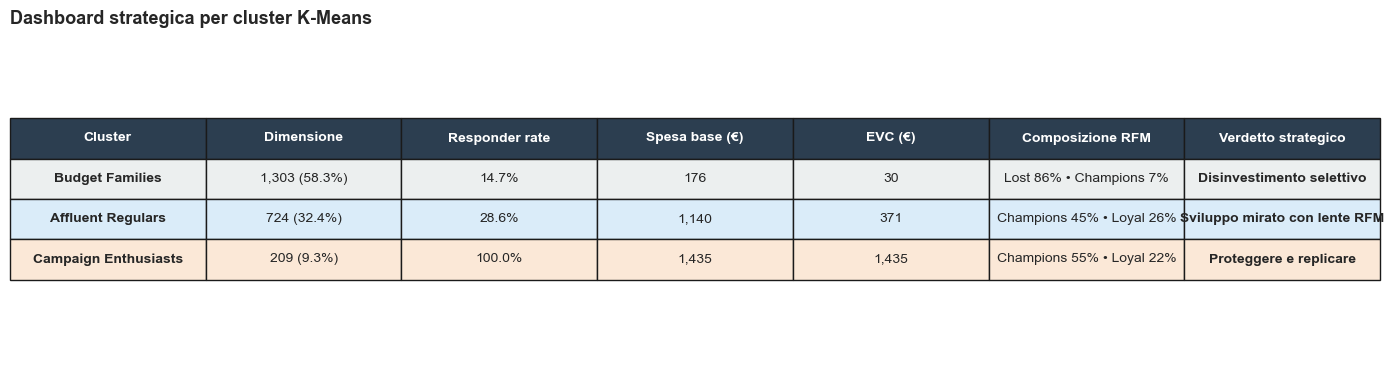

In [15]:
# Dashboard strategica per cluster

# Tabella-sintesi che allinea dimensione, responsività, valore
# ed economia di contatto per ciascun cluster K-Means, con due
# colonne qualitative: composizione RFM (top 2 segmenti) e
# verdetto strategico.

# ============================================================

# Calcolo composizione RFM per cluster

comp_rfm = (
    pd.crosstab(df['KMeans_Cluster'], df['RFM_Segment'], normalize='index') * 100
).round(1)
comp_rfm = comp_rfm.reindex(ORDER_KMEANS)

# Per ogni cluster, prendi i due segmenti RFM dominanti
composizione_stringhe = {}
for cluster in ORDER_KMEANS:
    row = comp_rfm.loc[cluster].sort_values(ascending=False)
    top1_name, top1_val = row.index[0], row.iloc[0]
    top2_name, top2_val = row.index[1], row.iloc[1]
    composizione_stringhe[cluster] = f"{top1_name} {top1_val:.0f}% • {top2_name} {top2_val:.0f}%"

# ============================================================

# Costruzione della tabella dashboard

verdetti_strategici = {
    'Campaign Enthusiasts': 'Proteggere e replicare',
    'Affluent Regulars':    'Sviluppo mirato con lente RFM',
    'Budget Families':      'Disinvestimento selettivo'
}

dashboard_rows = []
n_totale_df = len(df)
for cluster in ORDER_KMEANS:
    sub = df[df['KMeans_Cluster'] == cluster]
    n_cluster = len(sub)
    responder_rate = sub['is_responder'].mean() * 100
    spesa_base = sub['MntTotal'].mean()
    responder_mask = sub['is_responder'] == 1
    spesa_responder = sub.loc[responder_mask, 'MntTotal'].mean()
    evc = (responder_rate / 100) * spesa_responder
    
    dashboard_rows.append({
        'Cluster': cluster,
        'Dimensione': f"{n_cluster:,} ({n_cluster/n_totale_df*100:.1f}%)",
        'Responder rate': f"{responder_rate:.1f}%",
        'Spesa base (€)': f"{spesa_base:,.0f}",
        'EVC (€)': f"{evc:,.0f}",
        'Composizione RFM': composizione_stringhe[cluster],
        'Verdetto strategico': verdetti_strategici[cluster]
    })

dashboard = pd.DataFrame(dashboard_rows).set_index('Cluster')

# ============================================================

# Output testuale

print("=" * 110)
print("DASHBOARD STRATEGICA — sintesi per cluster")
print("=" * 110)
print(dashboard.to_string())
print("=" * 110)

# ============================================================

# Visualizzazione: tabella formattata con matplotlib

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.axis('off')

# Preparazione celle
cell_text = dashboard.reset_index().values.tolist()
col_labels = ['Cluster'] + list(dashboard.columns)

# Colori di sfondo: una riga colorata per cluster secondo PALETTE_KMEANS,
# con saturazione ridotta per leggibilità
def lighten(hex_color, amount=0.85):
    """Schiarisce un colore esadecimale miscelandolo con il bianco."""
    hex_color = hex_color.lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))
    lightened = tuple(c + (1 - c) * amount for c in rgb)
    return lightened

cell_colors = []
for cluster in ORDER_KMEANS:
    bg = lighten(PALETTE_KMEANS[cluster], amount=0.82)
    cell_colors.append([bg] * len(col_labels))

# Header colorato scuro
header_colors = ['#2c3e50'] * len(col_labels)

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellColours=cell_colors,
    colColours=header_colors,
    cellLoc='center',
    loc='center'
)

# Styling
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.2)

# Testo bianco nell'header
for i in range(len(col_labels)):
    cell = tbl[(0, i)]
    cell.set_text_props(color='white', fontweight='bold')

# Verdetto strategico in grassetto
col_verdetto_idx = len(col_labels) - 1
for i in range(1, len(ORDER_KMEANS) + 1):
    cell = tbl[(i, col_verdetto_idx)]
    cell.set_text_props(fontweight='bold')

# Nome del cluster in grassetto (prima colonna)
for i in range(1, len(ORDER_KMEANS) + 1):
    cell = tbl[(i, 0)]
    cell.set_text_props(fontweight='bold')

plt.title(
    'Dashboard strategica per cluster K-Means',
    fontsize=13, fontweight='bold', loc='left', pad=10
)

plt.tight_layout()
plt.show()

## 3.1 — Campaign Enthusiasts: proteggere e replicare

**Con 209 clienti (9.3% della popolazione) ma un EVC di 1.435€ — 47× il cluster più basso — i Campaign Enthusiasts concentrano una quota sproporzionata del valore generato dalle campagne. La raccomandazione strategica è doppia: proteggere la loro fidelizzazione e usare il loro profilo come modello di acquisizione per nuovi clienti.**

La componente di *protezione* è prioritaria perché questo cluster è la cassaforte di valore del marketing budget: i 209 clienti hanno una spesa media di 1.435€ negli ultimi due anni e una responsività totale al 100%, caratteristiche che non si rimpiazzano facilmente. Il rischio principale è il churn silenzioso — un Enthusiast che smette di acquistare senza preavviso. La leva operativa è il monitoraggio sistematico della variabile `Recency`: un Enthusiast che supera i 60-90 giorni dall'ultimo acquisto deve attivare un flag di allerta e una campagna di riattivazione mirata. Su questa popolazione il costo-per-contatto può essere elevato senza compromettere il ROI, perché ogni contatto recupera un cliente dal valore atteso vicino a 1.400€. Rientra qui in modo naturale il mini-target dei **41 At-Risk-Enthusiasts** identificati nel Notebook 04, che saranno oggetto di raccomandazione dedicata nella Sezione 4.

La componente di *replica* è la parte più ambiziosa della raccomandazione, e risponde a una domanda che la sola analisi storica non può affrontare: come acquisire nuovi Enthusiasts? Il profilo socio-demografico di questo cluster — reddito alto, pochi o nessun figlio, spesa premium concentrata su vini e carne — è identificabile con precisione e può essere usato come **profilo look-a-like** per campagne di acquisizione su pubblici esterni (es. su piattaforme advertising con targeting demografico). Non si tratta di "replicare campagne" ma di **replicare il profilo del cliente target**, ribaltando la logica: anziché sparare campagne a chi abbiamo e vedere chi risponde, partiamo dal profilo di chi risponde bene e cerchiamo clienti simili.

In termini di allocazione di budget, i Campaign Enthusiasts giustificano una quota sproporzionata rispetto alla loro numerosità. Una ripartizione di massima coerente con l'EVC assegnerebbe a questo cluster **il 40-50% del budget totale delle campagne**, nonostante rappresenti meno del 10% della popolazione. Il rimanente si distribuisce sugli altri due cluster secondo le raccomandazioni che seguono.

## 3.2 — Affluent Regulars: sviluppo mirato con lente RFM

**Con 724 clienti (32.4% della popolazione) e un EVC di 371€, gli Affluent Regulars sono il cluster "mainstream" dove si gioca la partita principale di crescita. Contengono clienti in momenti del ciclo di vita molto diversi: è qui che la lente RFM diventa operativamente essenziale per differenziare il tipo di azione.**

La componente Champions + Loyal (71% del cluster, ~510 clienti) rappresenta la base attiva consolidata: ad alta spesa, comportamento stabile, bassa urgenza di riattivazione. La strategia naturale è cross-sell e upsell, focalizzata non sulla frequenza d'acquisto (già buona) ma sul basket size — in particolare con leva sulle categorie complementari a vini e carne, che dominano il business al 77% combinato, lasciando spazio significativo di crescita su pesce, frutta e dolci.

La componente At Risk (23%, 168 clienti) è invece **il vero punto di leva tattico del blocco**: clienti con profilo di spesa Affluent (~1.100€) che si stanno raffreddando ma con potenziale intatto. Dalla Sezione 1 sappiamo che un Lost ha responsività media di 0.20 campagne contro le 0.57 di un At Risk: perdere un At Risk significa perdere quasi due terzi della sua responsività storica. Questo è il gruppo dove le campagne di riattivazione mirate (sconti personalizzati, reminder incentivanti) hanno il rapporto costo-beneficio più favorevole dell'intero notebook. I 44 Lost del cluster, in confronto, possono essere lasciati andare.

In termini di allocazione, il cluster giustifica **il 40-45% del budget totale**, coerentemente con la sua dimensione e con il fatto che contiene il sottogruppo At Risk — il punto di azione a più alto ritorno atteso una volta esclusi gli Enthusiasts.

## 3.3 — Budget Families: disinvestimento selettivo

**Con 1.303 clienti (58.3% della popolazione) e un EVC di appena 30€, le Budget Families rappresentano la maggioranza della base clienti ma solo una frazione marginale del valore generato dalle campagne. La raccomandazione strategica è di ridurre drasticamente l'investimento pubblicitario sul cluster, mantenendo presidio solo attraverso canali a costo marginale minimo.**

La struttura del cluster chiarisce il motivo: l'86% è Lost (1.116 clienti), il responder rate è sotto il 15%, e la spesa base del cluster è di soli 176€. Anche dove le campagne "funzionano" in senso statistico — l'uplift intra-cluster responder vs non-responder è del +21%, simile a quello degli Affluent Regulars — il guadagno assoluto è di soli 36€ per responder, contro i 218€ degli Affluent. A parità di costo di contatto, l'euro investito qui rende circa sei volte di meno.

L'ipotesi dei cacciatori di deal, emersa nella Sezione 2, rafforza la raccomandazione di cautela: i 30 super-responder del cluster (clienti con ≥2 campagne accettate) spendono in media 89€, **la metà dei non-super-responder**. Il pattern suggerisce che le campagne promozionali ad alto incentivo non attraggono valore nuovo ma lo cannibalizzano — attivando clienti opportunistici che comprano solo in sconto. La raccomandazione operativa che ne deriva è di **evitare del tutto le campagne promozionali costose** su questo cluster (direct mail, telemarketing, coupon cartacei) e limitarsi a canali automatizzati a costo unitario prossimo a zero: email newsletter, retargeting digitale, messaggi di servizio.

In termini di allocazione, il cluster giustifica **non più del 5-10% del budget totale**, nonostante rappresenti quasi il 60% della popolazione. È uno dei risultati più controintuitivi del notebook — e proprio per questo, uno dei più difendibili analiticamente.

# Sezione 4 — Sottogruppi ibridi e sintesi finale

## Obiettivo

La Sezione 3 ha prodotto raccomandazioni di allocazione budget articolate per i tre cluster K-Means. Questa sezione chiude il notebook in tre momenti: dedica attenzione a **due sottogruppi ibridi strategici** emersi nell'incrocio RFM × K-Means del Notebook 04 — piccoli per numerosità ma sproporzionati per rilevanza tattica; **consolida l'allocazione budget complessiva** in una visualizzazione unica che contrappone quota di popolazione e quota di investimento raccomandato; e **risponde in modo diretto alla domanda di business** che ha guidato l'intero progetto.

I due sottogruppi ibridi sono il prodotto più caratteristico dell'approccio di segmentazione ibrida adottato: né la RFM da sola né il K-Means da solo li avrebbero isolati, ma la loro intersezione rivela target tattici di alto valore.

## 4.1 — I 41 At-Risk-Enthusiasts: la priorità massima di riattivazione

**I 41 clienti che sono simultaneamente At Risk per la RFM e Campaign Enthusiasts per il K-Means sono il target tattico a più alta priorità del notebook. Combinano una responsività eccezionale alle campagne con un segnale di raffreddamento recente: l'intervento va fatto *ora*, prima che transitino verso Lost.**

Questi clienti non emergono da nessuna delle due segmentazioni prese singolarmente. Dentro gli At Risk RFM (249 clienti totali) sono solo una minoranza del 16%. Dentro i Campaign Enthusiasts (209 clienti totali) sono il 20%, mescolati con Champions e Loyal che richiedono azioni molto diverse. Solo l'incrocio dei due metodi li isola come gruppo coerente: alta responsività storica (per definizione Enthusiasts hanno accettato ≥2 campagne) ma `Recency` elevata che ne segnala il potenziale churn imminente.

La raccomandazione operativa è netta: campagna di riattivazione dedicata, a costo-per-contatto anche elevato, lanciata entro le prossime settimane. Il calcolo è semplice: se anche una frazione significativa di questi 41 clienti viene recuperata al comportamento Enthusiasts "pieno", il ritorno atteso supera qualsiasi campagna mainstream. Al contrario, se scivolano verso Lost, il costo di riacquisizione sarà molto più alto del costo di riattivazione fatto oggi.

## 4.2 — I 51 Lost-non-Budget: candidati win-back selettivo

**I 51 clienti Lost per la RFM ma *non* Budget Families per il K-Means (cioè Affluent Regulars-Lost o Enthusiasts-Lost) rappresentano un sottogruppo diverso dal precedente: non hanno l'urgenza temporale degli At-Risk-Enthusiasts, ma conservano un profilo socio-economico da clienti di valore, e sono quindi candidati a campagne di win-back mirate.**

La distinzione dai Lost "standard" è sostanziale. I 1.116 Lost dentro Budget Families (86% del totale Lost) sono clienti con profilo economico basso e bassa responsività strutturale: la Sezione 3.3 ha già stabilito che su questo sottogruppo le campagne hanno rendimento marginale. I 51 Lost-non-Budget sono invece clienti che *erano* ad alto valore — 44 Affluent Regulars e 7 Enthusiasts che si sono raffreddati oltre la soglia At Risk. La loro `Recency` elevata rende la probabilità di ritorno più bassa rispetto agli At-Risk-Enthusiasts, ma il valore potenziale in caso di riattivazione è paragonabile.

La raccomandazione è di un **win-back selettivo**: campagna dedicata a basso costo-per-contatto (email o retargeting digitale), con messaggio di riattivazione incentivato. Dato il rapporto costo-beneficio più incerto rispetto al sottogruppo precedente, ha senso trattarlo come un'iniziativa di secondo livello — non prioritaria, ma economicamente razionale fintanto che il costo di contatto resta contenuto.

ALLOCAZIONE BUDGET RACCOMANDATA — confronto con quota-popolazione
Cluster                       Pop. %   Budget %       Leva
----------------------------------------------------------------------
Budget Families                58.3%         8%    0.1× ↓↓
Affluent Regulars              32.4%        42%    1.3× ~
Campaign Enthusiasts            9.3%        45%    4.8× ↑↑
----------------------------------------------------------------------
Totale allocato                             95%
Riserva tattica                              5%


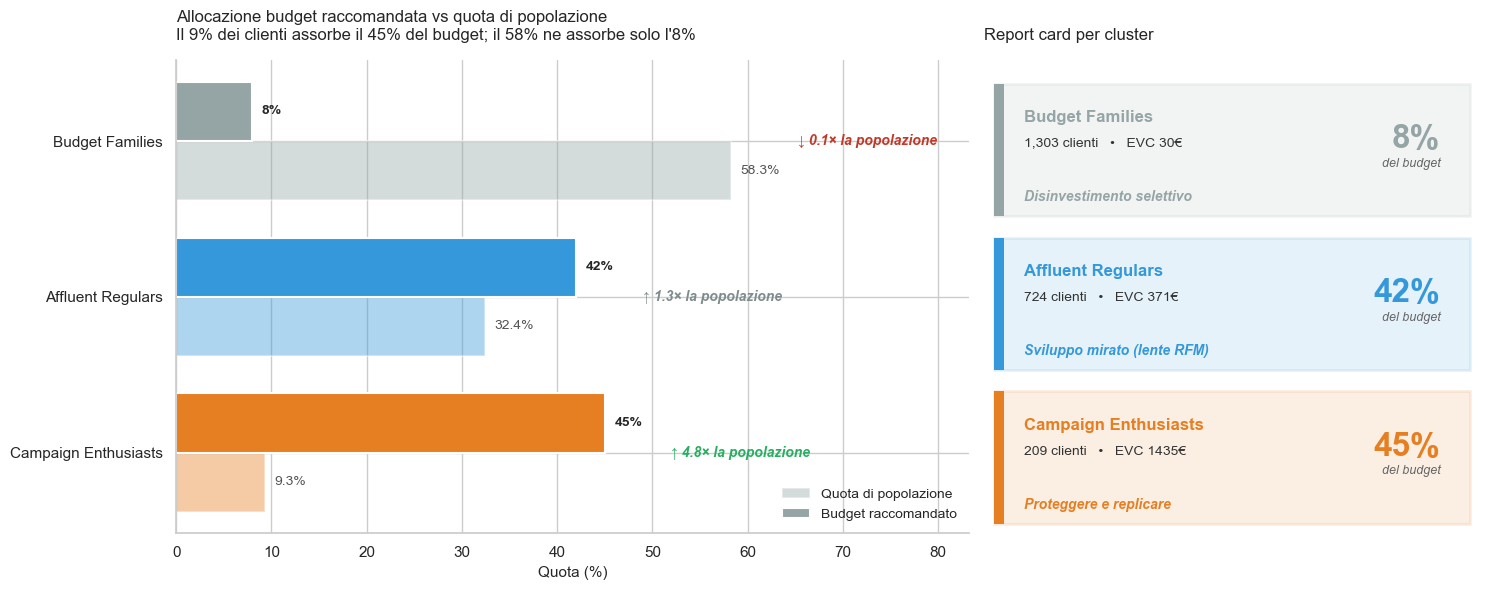

In [16]:
# Consolidamento visivo dell'allocazione budget raccomandata

# Visualizzazione sintetica che contrappone la quota di popolazione
# di ciascun cluster con la quota di budget raccomandata dalle
# Sezioni 3.1 / 3.2 / 3.3. Il contrasto tra le due quote è
# l'espressione visiva della tesi strategica del notebook.

# ============================================================

# Definizione dei valori centrali dell'allocazione raccomandata

# Valori coerenti con i range delle Sezioni 3.1-3.3:
#   Enthusiasts:      40-50%   → centro 45%
#   Affluent:         40-45%   → centro 42%
#   Budget Families:  5-10%    → centro  8%
#   Totale:           95%  (il 5% residuo è riserva tattica)

allocazione_raccomandata = {
    'Campaign Enthusiasts': 45,
    'Affluent Regulars':    42,
    'Budget Families':       8
}

# Calcolo quote-popolazione dalla dashboard
quote_popolazione = {
    cluster: len(df[df['KMeans_Cluster'] == cluster]) / len(df) * 100
    for cluster in ORDER_KMEANS
}

# Tabella di sintesi testuale
print("=" * 70)
print("ALLOCAZIONE BUDGET RACCOMANDATA — confronto con quota-popolazione")
print("=" * 70)
print(f"{'Cluster':<25} {'Pop. %':>10} {'Budget %':>10} {'Leva':>10}")
print("-" * 70)
for cluster in ORDER_KMEANS:
    pop = quote_popolazione[cluster]
    bud = allocazione_raccomandata[cluster]
    leva = bud / pop
    marker = '↑↑' if leva > 2 else ('↓↓' if leva < 0.5 else '~')
    print(f"{cluster:<25} {pop:>9.1f}% {bud:>9.0f}% {leva:>6.1f}× {marker}")
print("-" * 70)
print(f"{'Totale allocato':<25} {'':>10} {sum(allocazione_raccomandata.values()):>9.0f}%")
print(f"{'Riserva tattica':<25} {'':>10} {100 - sum(allocazione_raccomandata.values()):>9.0f}%")

# ============================================================

# Visualizzazione a due pannelli

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         gridspec_kw={'width_ratios': [1.6, 1]})

# -----------------------------------------------------------
# Pannello sinistro: bar chart comparativo orizzontale
# -----------------------------------------------------------
ax = axes[0]

y_pos = np.arange(len(ORDER_KMEANS))
bar_h = 0.38

# Barre quota-popolazione (chiare)
bars_pop = ax.barh(y_pos + bar_h/2,
                   [quote_popolazione[c] for c in ORDER_KMEANS],
                   height=bar_h,
                   color=[PALETTE_KMEANS[c] for c in ORDER_KMEANS],
                   alpha=0.4,
                   edgecolor='white', linewidth=1.5,
                   label='Quota di popolazione')

# Barre quota-budget (saturate)
bars_bud = ax.barh(y_pos - bar_h/2,
                   [allocazione_raccomandata[c] for c in ORDER_KMEANS],
                   height=bar_h,
                   color=[PALETTE_KMEANS[c] for c in ORDER_KMEANS],
                   edgecolor='white', linewidth=1.5,
                   label='Budget raccomandato')

# Etichette numeriche
for i, cluster in enumerate(ORDER_KMEANS):
    pop = quote_popolazione[cluster]
    bud = allocazione_raccomandata[cluster]
    ax.text(pop + 1, y_pos[i] + bar_h/2,
            f'{pop:.1f}%', va='center', fontsize=10, color='#555')
    ax.text(bud + 1, y_pos[i] - bar_h/2,
            f'{bud}%', va='center', fontsize=10, fontweight='bold')

# Annotazione leva (multiplo budget/popolazione) al termine delle barre più lunghe
for i, cluster in enumerate(ORDER_KMEANS):
    pop = quote_popolazione[cluster]
    bud = allocazione_raccomandata[cluster]
    leva = bud / pop
    color_leva = '#27ae60' if leva > 1.5 else ('#c0392b' if leva < 0.5 else '#7f8c8d')
    symbol = '↑' if leva > 1 else ('↓' if leva < 1 else '=')
    ax.text(max(pop, bud) + 7, y_pos[i],
            f'{symbol} {leva:.1f}× la popolazione',
            va='center', fontsize=10, fontweight='bold',
            color=color_leva, style='italic')

ax.set_yticks(y_pos)
ax.set_yticklabels(ORDER_KMEANS, fontsize=11)
ax.set_xlabel('Quota (%)', fontsize=11)
ax.set_xlim(0, max(max(quote_popolazione.values()),
                   max(allocazione_raccomandata.values())) + 25)
ax.set_title(
    "Allocazione budget raccomandata vs quota di popolazione\n"
    "Il 9% dei clienti assorbe il 45% del budget; il 58% ne assorbe solo l'8%",
    fontsize=12, loc='left', pad=15
)
ax.legend(loc='lower right', frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()   # Enthusiasts in alto, Budget in basso: gerarchia di valore

# -----------------------------------------------------------
# Pannello destro: report card numerica per cluster
# -----------------------------------------------------------
ax = axes[1]
ax.axis('off')

# Calcolo degli EVC (già calcolati, li ricarichiamo da evc_df per coerenza)
evc_per_cluster = {c: evc_df.loc[c, 'EVC (€)'] for c in ORDER_KMEANS}
n_per_cluster = {c: len(df[df['KMeans_Cluster'] == c]) for c in ORDER_KMEANS}

verdetti_brevi = {
    'Campaign Enthusiasts': 'Proteggere e replicare',
    'Affluent Regulars':    'Sviluppo mirato (lente RFM)',
    'Budget Families':      'Disinvestimento selettivo'
}

# Disegno delle "card" come rettangoli con testo
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

card_height = 0.28
card_gap = 0.045
y_start = 0.95

for i, cluster in enumerate(ORDER_KMEANS):
    y_top = y_start - i * (card_height + card_gap)
    y_bot = y_top - card_height
    
    # Rettangolo di sfondo
    color = PALETTE_KMEANS[cluster]
    rect = plt.Rectangle(
        (0.02, y_bot), 0.96, card_height,
        facecolor=color, alpha=0.12,
        edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)
    
    # Barretta colorata a sinistra (accent bar)
    accent = plt.Rectangle(
        (0.02, y_bot), 0.02, card_height,
        facecolor=color, edgecolor='none'
    )
    ax.add_patch(accent)
    
    # Testo principale del cluster
    ax.text(0.08, y_top - 0.055,
            cluster,
            fontsize=12, fontweight='bold', color=color, va='top')
    
    # Metriche chiave
    ax.text(0.08, y_top - 0.115,
            f"{n_per_cluster[cluster]:,} clienti   •   EVC {evc_per_cluster[cluster]:.0f}€",
            fontsize=10, color='#333', va='top')
    
    # Allocazione raccomandata in grande
    ax.text(0.92, y_top - 0.085,
            f"{allocazione_raccomandata[cluster]}%",
            fontsize=24, fontweight='bold', color=color,
            ha='right', va='top')
    ax.text(0.92, y_top - 0.155,
            "del budget",
            fontsize=9, color='#666',
            ha='right', va='top', style='italic')
    
    # Verdetto strategico in fondo
    ax.text(0.08, y_top - 0.225,
            verdetti_brevi[cluster],
            fontsize=10, color=color, va='top', style='italic', fontweight='bold')

ax.set_title('Report card per cluster', fontsize=12, loc='left', pad=15)

plt.tight_layout()
plt.show()

# Sintesi finale — risposta alla domanda di business

## Richiamo della domanda

Il progetto è stato guidato fin dall'inizio da una singola domanda:

> *"Come dovrebbe un'azienda food & beverage ottimizzare l'allocazione del budget delle prossime campagne marketing, basandosi sul comportamento storico dei suoi clienti?"*

La risposta costruita nelle cinque sezioni del notebook si articola in tre punti.

## Risposta strutturata

**1. Riallocazione aggressiva del budget secondo la gerarchia di valore osservata.** L'analisi dell'Expected Value per Contact ha quantificato un rapporto di 47× tra il cluster più redditizio (Campaign Enthusiasts, EVC 1.435€) e quello meno redditizio (Budget Families, EVC 30€). La raccomandazione operativa è di allocare circa il 45% del budget ai Campaign Enthusiasts (9% della popolazione), circa il 42% agli Affluent Regulars (32%), e non più dell'8% alle Budget Families (58%), con un 5% tenuto come riserva tattica. Questa distribuzione è deliberatamente sproporzionata rispetto alla dimensione dei cluster — è esattamente questa sproporzione la risposta sostanziale alla domanda di business. All'interno delle Budget Families vale inoltre l'ulteriore accortezza di evitare campagne promozionali costose, poiché l'anomalia osservata nei super-responder del cluster suggerisce che queste attraggono cacciatori di deal che cannibalizzano margine piuttosto che generarne.

**2. Differenziazione tattica all'interno di Affluent Regulars con lente RFM.** Il cluster "mainstream" non va trattato come monolite. Dentro i suoi 724 clienti, la componente Champions + Loyal (71%) richiede azioni di cross-sell e upsell sul basket size; la componente At Risk (23%, 168 clienti) è invece il punto di leva tattico a più alto rendimento marginale dell'intero dataset, e merita campagne di riattivazione dedicate prima che questi clienti transitino a Lost. La distinzione è resa possibile dalla segmentazione RFM usata come lente tattica sovrapposta alla segmentazione K-Means strategica — l'approccio ibrido che ha guidato l'intero notebook.

**3. Azioni mirate sui due sottogruppi ibridi identificati all'intersezione delle due segmentazioni.** I 41 At-Risk-Enthusiasts sono la priorità assoluta di riattivazione del notebook: combinano responsività eccezionale e raffreddamento recente, e vanno trattati con urgenza. I 51 Lost-non-Budget sono invece candidati a campagne di win-back selettivo, razionali solo a costo-per-contatto contenuto. Entrambi sono il prodotto caratteristico dell'approccio ibrido: nessuna delle due segmentazioni, presa singolarmente, li avrebbe isolati, e la loro rilevanza strategica rispetto alla loro numerosità è la giustificazione finale della scelta di averne usate due.

Le raccomandazioni qui formulate si fondano su un'analisi osservazionale del comportamento storico e vanno interpretate di conseguenza: indicano la direzione coerente con i dati disponibili, non un effetto causale dimostrato.